In [ ]:
# 2.4、2.5 微积分

In [7]:
import torch
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [8]:
x.requires_grad_(True)
x.grad
print(x.grad)

None


In [9]:
y = 2 * torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

In [10]:
# import torch
# x = torch.arange(4.0)
# x
# y = 2 * torch.dot(x,x)
# y

In [11]:
# 计算梯度
y.backward(retain_graph=True) 
x.grad

tensor([ 0.,  4.,  8., 12.])

In [12]:
x.grad.zero_()
y = x.sum()

In [13]:
y.backward()
x.grad

tensor([1., 1., 1., 1.])

In [14]:
x.grad.zero_()
y = x*x
y

tensor([0., 1., 4., 9.], grad_fn=<MulBackward0>)

In [15]:
y.sum().backward()

In [16]:
x.grad

tensor([0., 2., 4., 6.])

In [17]:
x.grad.zero_()
y = x*x
u = y.detach()
u

tensor([0., 1., 4., 9.])

In [18]:
z = u*x
z,z.sum()

(tensor([ 0.,  1.,  8., 27.], grad_fn=<MulBackward0>),
 tensor(36., grad_fn=<SumBackward0>))

In [19]:
z.sum().backward()

In [20]:
x.grad == u

tensor([True, True, True, True])

In [21]:
def f(a):
    b = a*2
    while b.norm()<1000:
        b=b*2
    if b.sum()>0:
        c=b
    else:
        c=100*b
    return c

a = torch.randn(size=(),requires_grad=True)
# a = torch.tensor(1.,requires_grad=True) 
d = f(a)
d.backward()
a.grad == d/a

tensor(True)

In [22]:
d

tensor(1197.0411, grad_fn=<MulBackward0>)

In [23]:
# 2.6 概率

In [24]:
import torch
from torch.distributions import multinomial
from d2l import torch as d2l

ModuleNotFoundError: No module named 'd2l'

In [25]:
fair_probs = torch.ones([6])/6
multinomial.Multinomial(1,fair_probs).sample()

tensor([0., 0., 0., 1., 0., 0.])

In [26]:
multinomial.Multinomial(10,fair_probs).sample()

tensor([1., 2., 3., 1., 2., 1.])

In [27]:
counts = multinomial.Multinomial(1000,fair_probs).sample()
counts/1000

tensor([0.1530, 0.1450, 0.1650, 0.1810, 0.1750, 0.1810])

In [28]:
multinomial.Multinomial(1000,fair_probs)

Multinomial()

In [29]:
counts = multinomial.Multinomial(10,fair_probs).sample((500,))
counts

tensor([[2., 1., 1., 1., 3., 2.],
        [2., 1., 2., 0., 3., 2.],
        [1., 0., 3., 3., 2., 1.],
        ...,
        [2., 0., 1., 1., 5., 1.],
        [3., 1., 2., 2., 1., 1.],
        [1., 1., 2., 1., 1., 4.]])

In [30]:
counts = multinomial.Multinomial(1,fair_probs).sample((500,))
counts

tensor([[0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1.],
        [1., 0., 0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0., 0.]])

In [31]:
counts = multinomial.Multinomial(10,fair_probs).sample((500,))
counts

tensor([[1., 0., 2., 1., 3., 3.],
        [4., 1., 2., 1., 1., 1.],
        [0., 1., 1., 2., 1., 5.],
        ...,
        [2., 2., 1., 1., 4., 0.],
        [1., 4., 1., 1., 0., 3.],
        [1., 2., 3., 1., 1., 2.]])

In [32]:
cum_counts = counts.cumsum(dim=0)
cum_counts

tensor([[  1.,   0.,   2.,   1.,   3.,   3.],
        [  5.,   1.,   4.,   2.,   4.,   4.],
        [  5.,   2.,   5.,   4.,   5.,   9.],
        ...,
        [803., 824., 836., 841., 842., 834.],
        [804., 828., 837., 842., 842., 837.],
        [805., 830., 840., 843., 843., 839.]])

In [33]:
a = cum_counts.sum(dim=1,keepdims=True)
a

tensor([[  10.],
        [  20.],
        [  30.],
        [  40.],
        [  50.],
        [  60.],
        [  70.],
        [  80.],
        [  90.],
        [ 100.],
        [ 110.],
        [ 120.],
        [ 130.],
        [ 140.],
        [ 150.],
        [ 160.],
        [ 170.],
        [ 180.],
        [ 190.],
        [ 200.],
        [ 210.],
        [ 220.],
        [ 230.],
        [ 240.],
        [ 250.],
        [ 260.],
        [ 270.],
        [ 280.],
        [ 290.],
        [ 300.],
        [ 310.],
        [ 320.],
        [ 330.],
        [ 340.],
        [ 350.],
        [ 360.],
        [ 370.],
        [ 380.],
        [ 390.],
        [ 400.],
        [ 410.],
        [ 420.],
        [ 430.],
        [ 440.],
        [ 450.],
        [ 460.],
        [ 470.],
        [ 480.],
        [ 490.],
        [ 500.],
        [ 510.],
        [ 520.],
        [ 530.],
        [ 540.],
        [ 550.],
        [ 560.],
        [ 570.],
        [ 580.],
        [ 590.

In [34]:
estimates = cum_counts/a
estimates

tensor([[0.1000, 0.0000, 0.2000, 0.1000, 0.3000, 0.3000],
        [0.2500, 0.0500, 0.2000, 0.1000, 0.2000, 0.2000],
        [0.1667, 0.0667, 0.1667, 0.1333, 0.1667, 0.3000],
        ...,
        [0.1612, 0.1655, 0.1679, 0.1689, 0.1691, 0.1675],
        [0.1611, 0.1659, 0.1677, 0.1687, 0.1687, 0.1677],
        [0.1610, 0.1660, 0.1680, 0.1686, 0.1686, 0.1678]])

In [35]:
import matplotlib.pyplot as plt

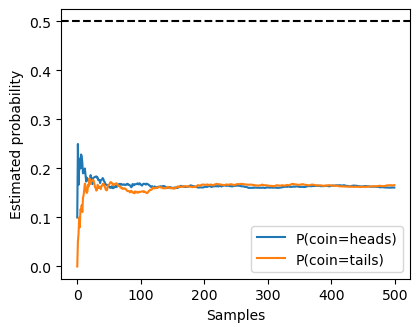

In [36]:
plt.figure(figsize=(4.5, 3.5))
plt.plot(estimates[:, 0], label=("P(coin=heads)"))
plt.plot(estimates[:, 1], label=("P(coin=tails)"))
plt.axhline(y=0.5, color='black', linestyle='dashed')
plt.gca().set_xlabel('Samples')
plt.gca().set_ylabel('Estimated probability')
plt.legend();